In [10]:
require(Seurat)

In [2]:
data <- read.delim('CNS.lv.expressionmatrix.rename.tsv', header = T, row.names = 1)

In [3]:
meta <- read.delim('CNS.lv.clusters.upload.rename.txt', header = T)
meta <- meta[-1, ]

In [4]:
# # Please ignore the attempt below to use raw data to generate an atlas, the raw data looks strange...
# raw1 <- Read10X_h5("GSM3764784_larva1_raw_gene_bc_matrices_h5.h5")
# raw2 <- Read10X_h5("GSM3764785_larva2_raw_gene_bc_matrices_h5.h5")
# raw3 <- Read10X_h5("GSM3764786_larva3_raw_gene_bc_matrices_h5.h5")

# rename <- function(name, number){
#     name <- sub("-[0-9]+$", "", name)
#     name <- paste('lv.', number, '_', name, '_CNS.lv', sep = '')
#     return(name)
# }

# colnames(raw1) <- rename(colnames(raw1), 1)
# colnames(raw2) <- rename(colnames(raw2), 2)
# colnames(raw3) <- rename(colnames(raw3), 3)


# # below is for ID correction: 
# # the downloaded data has different style of names
# # and wrong assignment of sample ID! there are only 3 samples for the larval stage
# colnames(data) <- sub("\\.[0-9]+(?=_CNS)", "",  colnames(data), perl = TRUE)
# colnames(data) <- gsub('lv.4', 'lv.2', colnames(data))
# table(sub("_.*", "", colnames(data)))


# lv1 <- CreateSeuratObject(counts = raw1[,colnames(raw1) %in% colnames(data)])
# lv2 <- CreateSeuratObject(counts = raw2[,colnames(raw2) %in% colnames(data)])
# lv3 <- CreateSeuratObject(counts = raw3[,colnames(raw3) %in% colnames(data)])
# Ciona <- merge(x = lv1, y = list(lv2, lv3))


# VlnPlot(Ciona, features = c('nCount_RNA'))

In [5]:
obj <- CreateSeuratObject(counts = data, assay = "RNA",
  project = "CNS.lv",
  meta.data = meta
)

Warning message:
“Data is of class data.frame. Coercing to dgCMatrix.”


In [6]:
obj@assays$RNA$data  <- obj@assays$RNA$counts
Idents(obj) <- 'Tissue.Type'

In [7]:
# put UMAP into atlas
tmp <- obj@meta.data[,c('X', 'Y')]
colnames(tmp) <- c('UMAP_1', 'UMAP_2')
tmp$UMAP_1 <- as.double(tmp$UMAP_1)
tmp$UMAP_2 <- as.double(tmp$UMAP_2)
umap_dr <- CreateDimReducObject(
  embeddings = as.matrix(tmp),
  key = "UMAP_",
  assay = DefaultAssay(obj)
)

obj[["umap"]] <- umap_dr

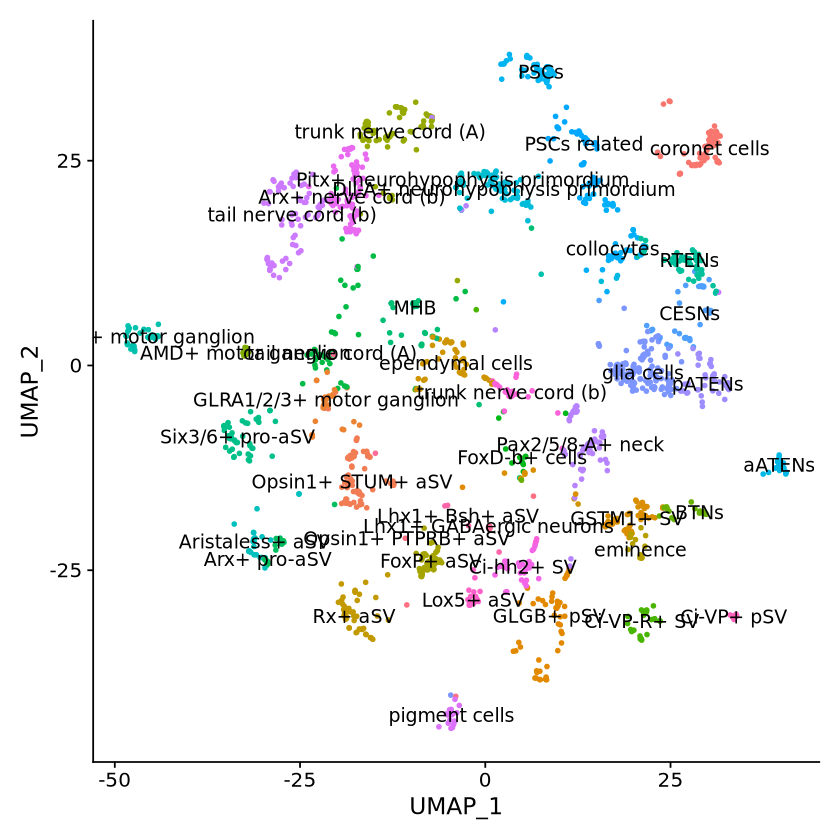

In [8]:
DimPlot(obj, label = T) + NoLegend()

In [14]:
saveRDS(obj, file = "Ciona_CNS_lv.rds")

In [15]:
# convert to h5ad, directly store Seurat normalised matrix
obj[["RNA"]] <- as(obj[["RNA"]], "Assay")
sceasy::convertFormat(obj, main_layer = "data", from="seurat", to="anndata",
                      outFile='Ciona_CNS_lv.h5ad')

AnnData object with n_obs × n_vars = 1704 × 13182
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'NAME', 'X', 'Y', 'Clusters', 'Tissue.Type'
    var: 'name'
    obsm: 'X_umap'